In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv("../data/raw/Credit_Card_Churn.csv")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,100000000,Existing Customer,57,F,0,Uneducated,Divorced,$40K - $60K,Blue,51,...,2,6,3206.56,1878.94,1327.62,1.07,13740,34,2.09,0.59
1,100000001,Attrited Customer,61,F,3,Post-Graduate,Single,$40K - $60K,Silver,19,...,2,6,5134.84,2498.54,2636.30,2.65,14279,64,0.61,0.49
2,100000002,Existing Customer,62,F,0,High School,Divorced,Less than $40K,Blue,31,...,6,3,20704.64,1581.42,19123.22,2.00,19353,41,1.36,0.08
3,100000003,Existing Customer,39,M,3,Doctorate,Married,$60K - $80K,Blue,20,...,0,5,28157.67,552.70,27604.97,2.56,18360,123,0.71,0.02
4,100000004,Existing Customer,52,F,3,Graduate,Single,$120K +,Blue,24,...,5,0,27955.43,1430.73,26524.70,0.60,1205,69,0.46,0.05


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10000 non-null  int64  
 1   Attrition_Flag            10000 non-null  object 
 2   Customer_Age              10000 non-null  int64  
 3   Gender                    10000 non-null  object 
 4   Dependent_count           10000 non-null  int64  
 5   Education_Level           10000 non-null  object 
 6   Marital_Status            10000 non-null  object 
 7   Income_Category           10000 non-null  object 
 8   Card_Category             10000 non-null  object 
 9   Months_on_book            10000 non-null  int64  
 10  Total_Relationship_Count  10000 non-null  int64  
 11  Months_Inactive_12_mon    10000 non-null  int64  
 12  Contacts_Count_12_mon     10000 non-null  int64  
 13  Credit_Limit              10000 non-null  float64
 14  Total_R

In [3]:
df.isna().sum().sort_values(ascending=False)

CLIENTNUM                   0
Attrition_Flag              0
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [4]:
df["Attrition_Flag"].value_counts(normalize=True)

Attrition_Flag
Existing Customer    0.8462
Attrited Customer    0.1538
Name: proportion, dtype: float64

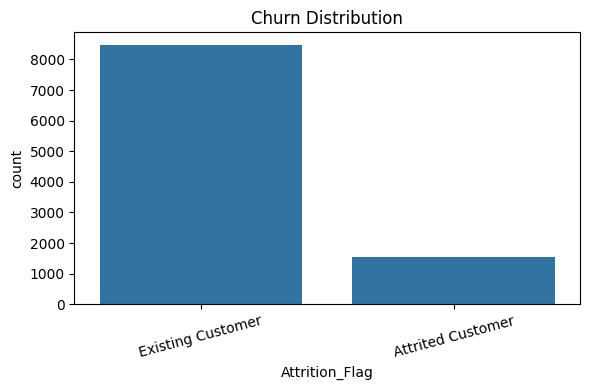

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Attrition_Flag")
plt.title("Churn Distribution")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
from pathlib import Path

# Load data
DATA_PATH = Path("../data/raw/Credit_Card_Churn.csv")
df = pd.read_csv(DATA_PATH)

# Clean column names a bit
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

# Create target if the dataset has Attrition_Flag
if "Attrition_Flag" in df.columns and "churned" not in df.columns:
    df["churned"] = df["Attrition_Flag"].map({
        "Attrited Customer": 1,
        "Existing Customer": 0
    })

# Basic dataset stats
total_rows, total_cols = df.shape
feature_cols = [c for c in df.columns if c != "churned"]
total_features = len(feature_cols)

# Missing values and duplicates
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = df.duplicated().sum()

# Target summary
if "churned" in df.columns:
    churn_counts = df["churned"].value_counts().sort_index()
    churn_rate = df["churned"].mean()
else:
    churn_counts = None
    churn_rate = None

print("DATASET SUMMARY")
print("=" * 50)
print(f"Total customers: {total_rows}")
print(f"Total columns: {total_cols}")
print(f"Total features (excluding target): {total_features}")
print(f"Duplicate rows: {duplicate_rows}")

if churn_counts is not None:
    print("\nTARGET DISTRIBUTION")
    print("-" * 50)
    print(f"Retained (0): {churn_counts.get(0, 0)}")
    print(f"Churned (1):   {churn_counts.get(1, 0)}")
    print(f"Churn rate:    {churn_rate:.2%}")

print("\nTOP 10 COLUMNS WITH MISSING VALUES")
print("-" * 50)
print(missing_values[missing_values > 0].head(10))

print("\nDATA TYPES")
print("-" * 50)
print(df.dtypes.value_counts())

print("\nFIRST 5 ROWS")
print("-" * 50)
display(df.head())

DATASET SUMMARY
Total customers: 10000
Total columns: 22
Total features (excluding target): 21
Duplicate rows: 0

TARGET DISTRIBUTION
--------------------------------------------------
Retained (0): 8462
Churned (1):   1538
Churn rate:    15.38%

TOP 10 COLUMNS WITH MISSING VALUES
--------------------------------------------------
Series([], dtype: int64)

DATA TYPES
--------------------------------------------------
int64      10
object      6
float64     6
Name: count, dtype: int64

FIRST 5 ROWS
--------------------------------------------------


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,churned
0,100000000,Existing Customer,57,F,0,Uneducated,Divorced,$40K - $60K,Blue,51,...,6,3206.56,1878.94,1327.62,1.07,13740,34,2.09,0.59,0
1,100000001,Attrited Customer,61,F,3,Post-Graduate,Single,$40K - $60K,Silver,19,...,6,5134.84,2498.54,2636.30,2.65,14279,64,0.61,0.49,1
2,100000002,Existing Customer,62,F,0,High School,Divorced,Less than $40K,Blue,31,...,3,20704.64,1581.42,19123.22,2.00,19353,41,1.36,0.08,0
3,100000003,Existing Customer,39,M,3,Doctorate,Married,$60K - $80K,Blue,20,...,5,28157.67,552.70,27604.97,2.56,18360,123,0.71,0.02,0
4,100000004,Existing Customer,52,F,3,Graduate,Single,$120K +,Blue,24,...,0,27955.43,1430.73,26524.70,0.60,1205,69,0.46,0.05,0
